প্রথমে ডেটা লোড করা

In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl.styles.builtins import normal

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ডেটা লোড (ফাইলের নাম transactions.csv ধরে নিচ্ছি)
df = pd.read_csv("transactions.csv")

print("ডেটার আকার:", df.shape)
print("\nপ্রথম ৫টা রো:")
display(df.head())

ডেটার আকার: (299695, 17)

প্রথম ৫টা রো:


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [114]:
print("কলাম ও টাইপের তথ্য:")
df.info()

print("\nমিসিং ভ্যালু গণনা:")
print(df.isnull().sum())

print("\nসংখ্যাগত কলামের সারাংশ:")
display(df.describe())

print("\nক্যাটাগরিক্যাল কলামের সারাংশ:")
display(df.describe(include='object'))

কলাম ও টাইপের তথ্য:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-nul

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud
count,299695.0000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000
mean,149848.0000,3002.559432,973.397871,50.673321,148.142973,177.165279,0.153640,0.837999,0.872110,0.784588,357.049028,0.022062
std,86514.6388,1732.309663,525.241409,5.976391,200.364624,306.926507,0.360603,0.368453,0.333968,0.411109,427.672074,0.146887
min,1.0000,1.000000,1.000000,40.000000,3.520000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74924.5000,1501.000000,516.000000,46.000000,46.190000,42.100000,0.000000,1.000000,1.000000,1.000000,136.600000,0.000000
50%,149848.0000,3007.000000,975.000000,51.000000,90.130000,89.990000,0.000000,1.000000,1.000000,1.000000,273.020000,0.000000
75%,224771.5000,4504.000000,1425.000000,56.000000,173.450000,191.110000,0.000000,1.000000,1.000000,1.000000,409.180000,0.000000
max,299695.0000,6000.000000,1890.000000,60.000000,4565.290000,16994.740000,1.000000,1.000000,1.000000,1.000000,3748.560000,1.000000



ক্যাটাগরিক্যাল কলামের সারাংশ:


,country,bin_country,channel,merchant_category,transaction_time
count,299695,299695,299695,299695,299695
unique,10,10,2,5,297975
top,US,US,web,electronics,2024-10-17T01:27:59Z
freq,32430,32295,152226,60220,3


# ধাপ ২: টার্গেট ভ্যারিয়েবল দেখা (is_fraud)

ফ্রডের বিতরণ:
is_fraud
0    293083
1      6612
Name: count, dtype: int64

পার্সেন্টেজে:
is_fraud
0    97.793757
1     2.206243
Name: proportion, dtype: float64


C:\Users\evan\AppData\Local\Temp\ipykernel_22104\3708075459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_fraud', data=df, palette='viridis')


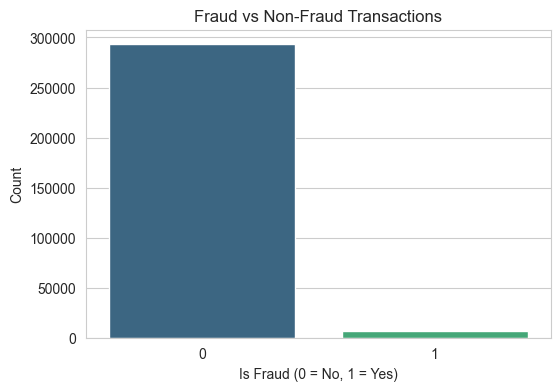

In [115]:
print("ফ্রডের বিতরণ:")
print(df['is_fraud'].value_counts())
print("\nপার্সেন্টেজে:")
print(df['is_fraud'].value_counts(normalize=True) * 100)

# ভিজুয়াল
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud', data=df, palette='viridis')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

পর্যবেক্ষণ (এই ডেটায়):

খুবই ইমব্যালেন্সড → ০ অনেক বেশি, ১ খুব কম (typical fraud dataset)
এর মানে → পরে class_weight বা SMOTE ব্যবহার করতে হবে

# ধাপ ৩: ক্যাটাগরিক্যাল কলামের ফ্রিকোয়েন্সি দেখা


country এর বিতরণ:
country
US    32430
GB    30602
FR    30343
NL    30220
TR    30074
PL    29965
RO    29501
DE    29060
ES    28885
IT    28615
Name: count, dtype: int64
country
US    10.821001
GB    10.211048
FR    10.124627
NL    10.083585
TR    10.034869
PL     9.998498
RO     9.843674
DE     9.696525
ES     9.638132
IT     9.548041
Name: proportion, dtype: float64


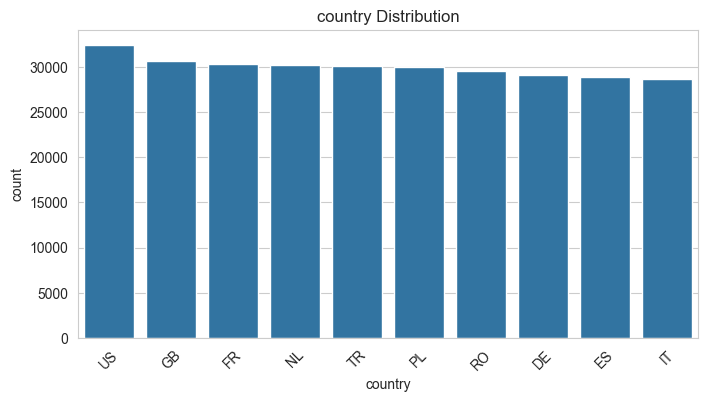


bin_country এর বিতরণ:
bin_country
US    32295
GB    30563
FR    30261
NL    30256
TR    29972
PL    29963
RO    29532
DE    29086
ES    29058
IT    28709
Name: count, dtype: int64
bin_country
US    10.775956
GB    10.198035
FR    10.097266
NL    10.095597
TR    10.000834
PL     9.997831
RO     9.854018
DE     9.705200
ES     9.695857
IT     9.579406
Name: proportion, dtype: float64


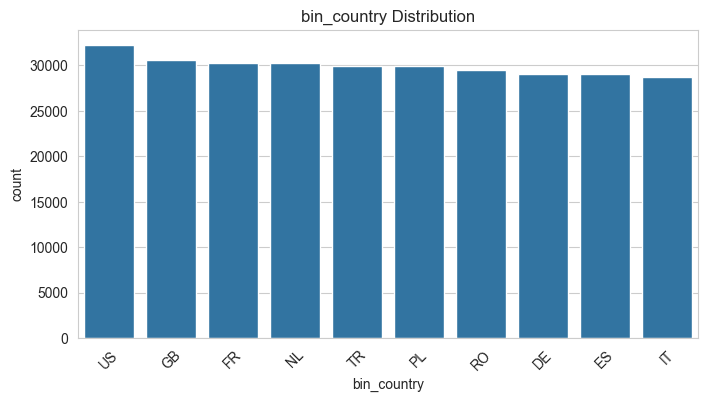


channel এর বিতরণ:
channel
web    152226
app    147469
Name: count, dtype: int64
channel
web    50.79364
app    49.20636
Name: proportion, dtype: float64


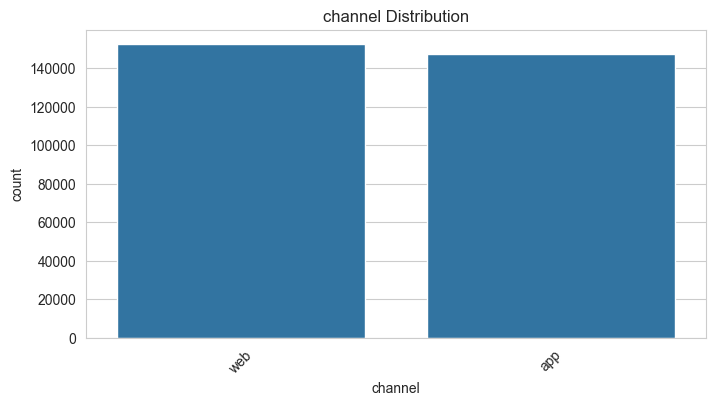


merchant_category এর বিতরণ:
merchant_category
electronics    60220
travel         59922
grocery        59913
gaming         59839
fashion        59801
Name: count, dtype: int64
merchant_category
electronics    20.093762
travel         19.994328
grocery        19.991325
gaming         19.966633
fashion        19.953953
Name: proportion, dtype: float64


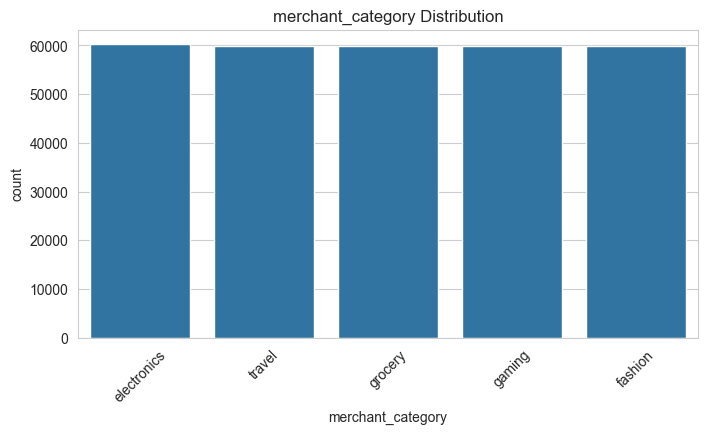


promo_used এর বিতরণ:
promo_used
0    253650
1     46045
Name: count, dtype: int64
promo_used
0    84.636047
1    15.363953
Name: proportion, dtype: float64


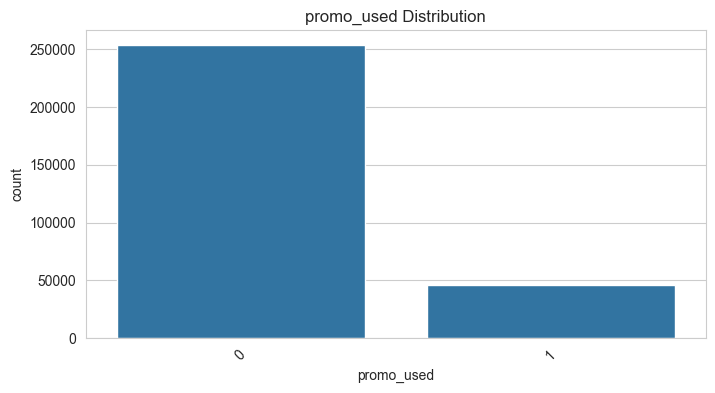


avs_match এর বিতরণ:
avs_match
1    251144
0     48551
Name: count, dtype: int64
avs_match
1    83.799863
0    16.200137
Name: proportion, dtype: float64


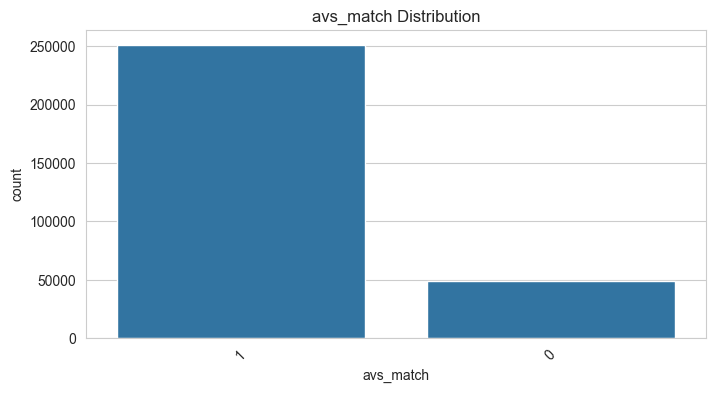


cvv_result এর বিতরণ:
cvv_result
1    261367
0     38328
Name: count, dtype: int64
cvv_result
1    87.210998
0    12.789002
Name: proportion, dtype: float64


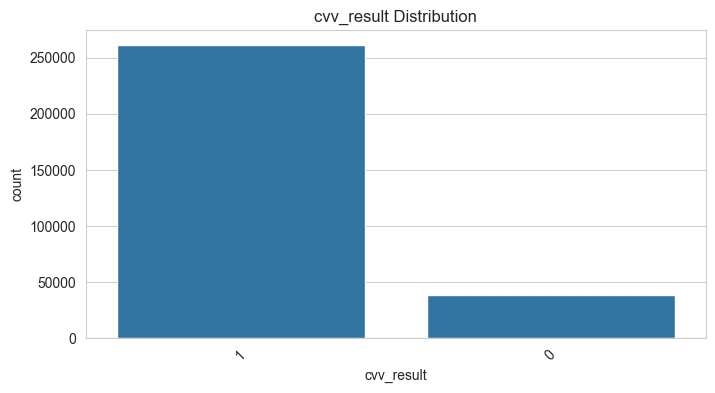


three_ds_flag এর বিতরণ:
three_ds_flag
1    235137
0     64558
Name: count, dtype: int64
three_ds_flag
1    78.458766
0    21.541234
Name: proportion, dtype: float64


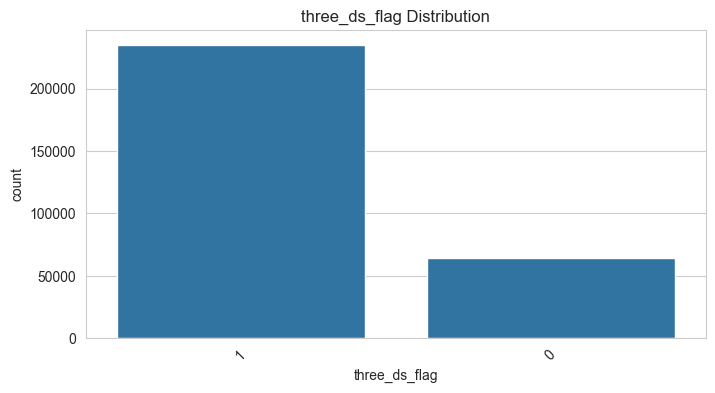

In [116]:
cat_cols = ['country', 'bin_country', 'channel', 'merchant_category', 'promo_used',
            'avs_match', 'cvv_result', 'three_ds_flag']

for col in cat_cols:
    print(f"\n{col} এর বিতরণ:")
    print(df[col].value_counts(dropna=False))
    print(df[col].value_counts(normalize=True, dropna=False) * 100)

    # ভিজুয়াল (যদি অনেক ক্যাটাগরি না থাকে)
    if df[col].nunique() <= 10:
        plt.figure(figsize=(8,4))
        sns.countplot(x=col, data=df, order=df[col].value_counts().index)
        plt.title(f"{col} Distribution")
        plt.xticks(rotation=45)
        plt.show()

কী দেখতে হবে?

কোন দেশ/চ্যানেল/ক্যাটাগরি খুব কম আছে কিনা
promo_used, avs_match, cvv_result, three_ds_flag → এগুলো binary (0/1) হওয়া উচিত

# ধাপ ৪: নিউমেরিক্যাল ফিচারের ডিস্ট্রিবিউশন

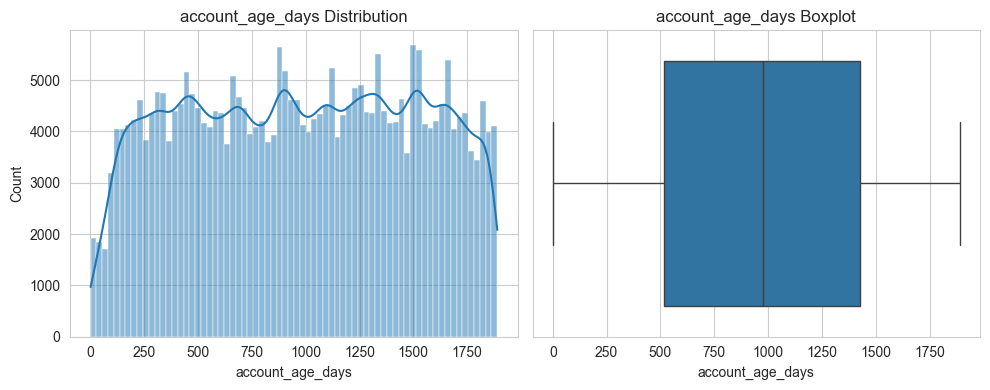

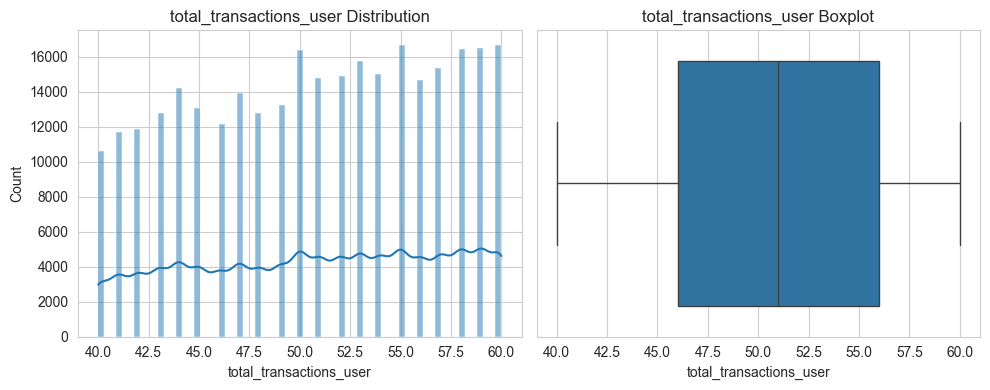

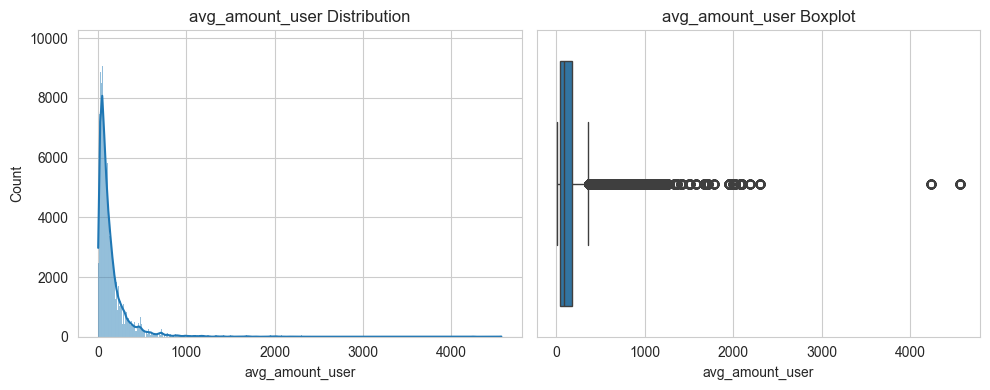

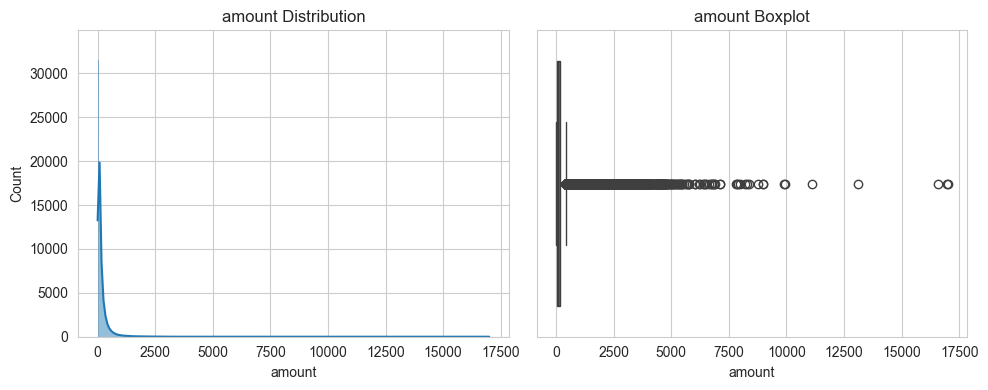

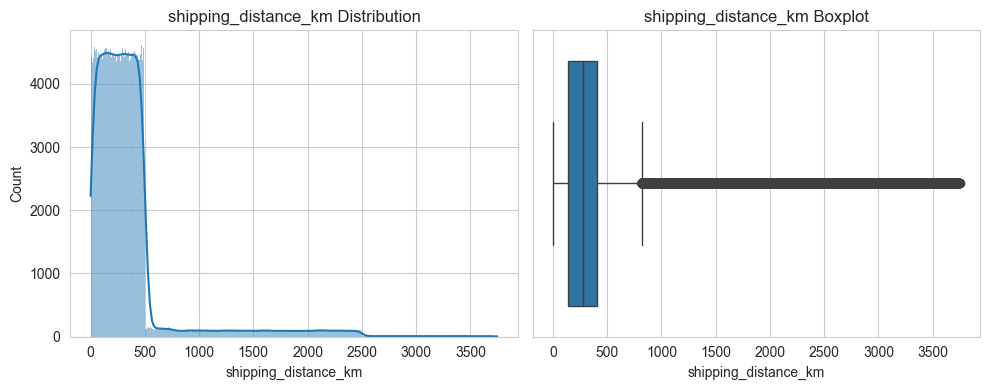

In [117]:
num_cols = ['account_age_days', 'total_transactions_user', 'avg_amount_user',
            'amount', 'shipping_distance_km']

for col in num_cols:
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")

    plt.tight_layout()
    plt.show()

কী দেখতে হবে?

amount এবং shipping_distance_km-এ অনেক আউটলায়ার আছে
account_age_days খুব ছোট/বড় মান আছে কিনা

# ধাপ ৫: ফ্রডের সাথে নিউমেরিক্যাল ফিচারের সম্পর্ক (Boxplot)

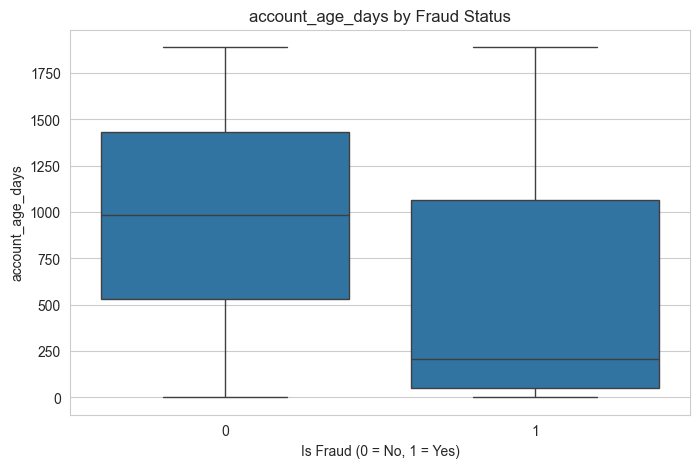

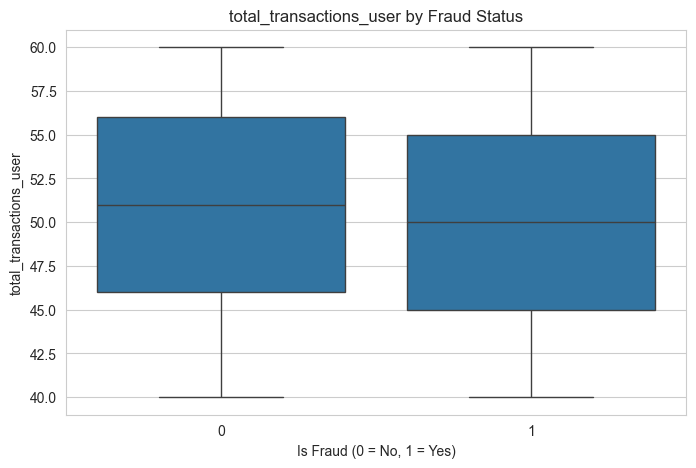

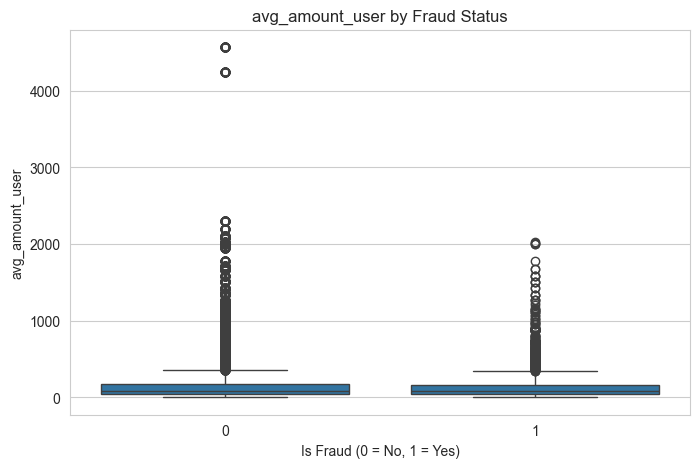

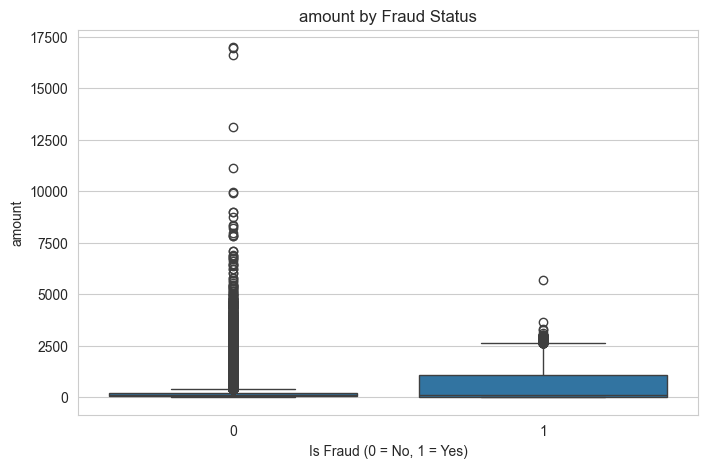

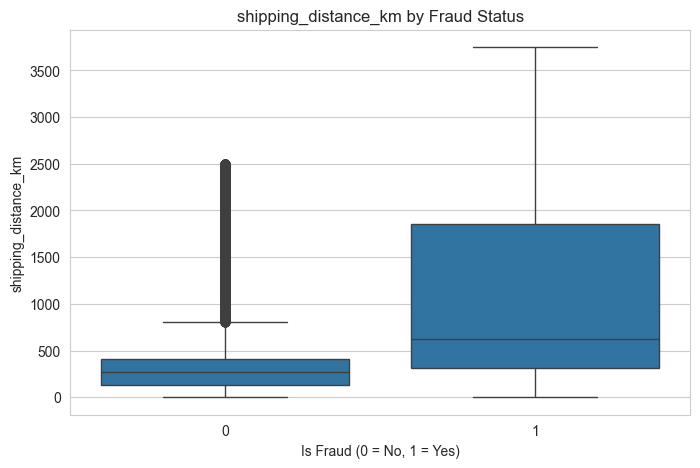

In [118]:
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='is_fraud', y=col, data=df)
    plt.title(f"{col} by Fraud Status")
    plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
    plt.show()

পর্যবেক্ষণের সম্ভাব্য পয়েন্ট:

ফ্রড ট্রানজেকশনে amount বেশি হতে পারে
shipping_distance_km বেশি হলে ফ্রডের সম্ভাবনা বাড়তে পারে

# ধাপ ৬: কোরিলেশন হিটম্যাপ

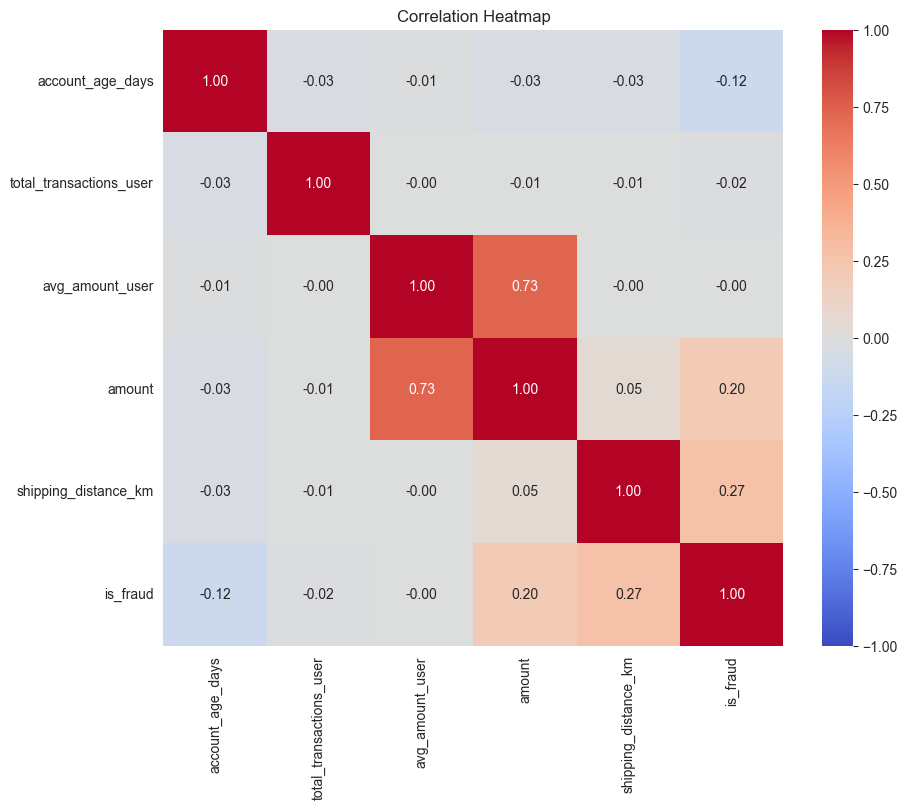

In [119]:
plt.figure(figsize=(10,8))
corr = df[num_cols + ['is_fraud']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

# ধাপ ৭: ক্যাটাগরিক্যাল ফিচার ও ফ্রডের সম্পর্ক

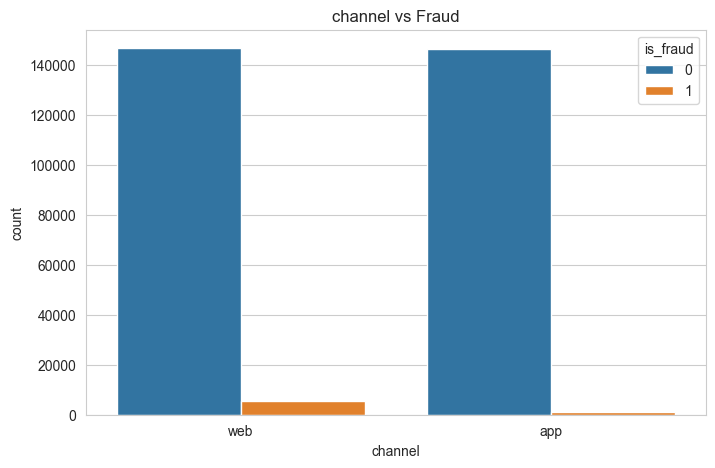

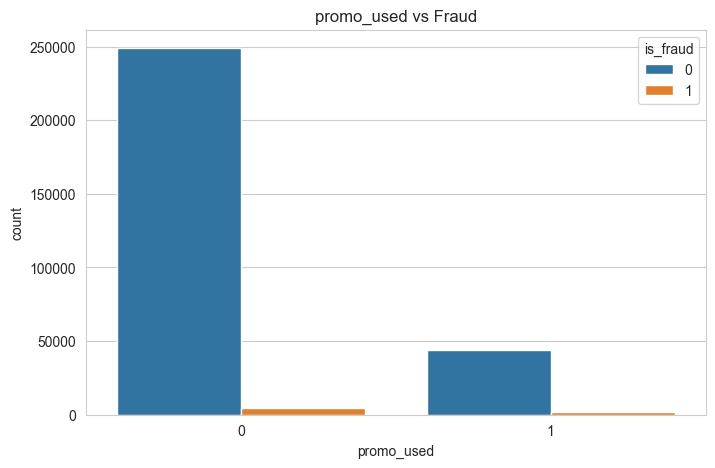

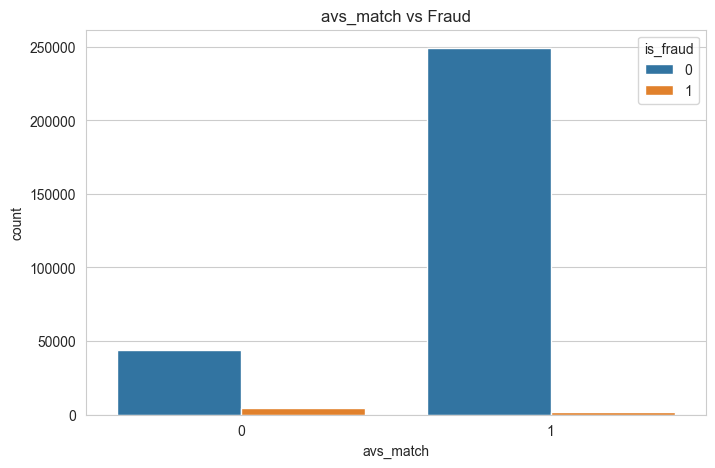

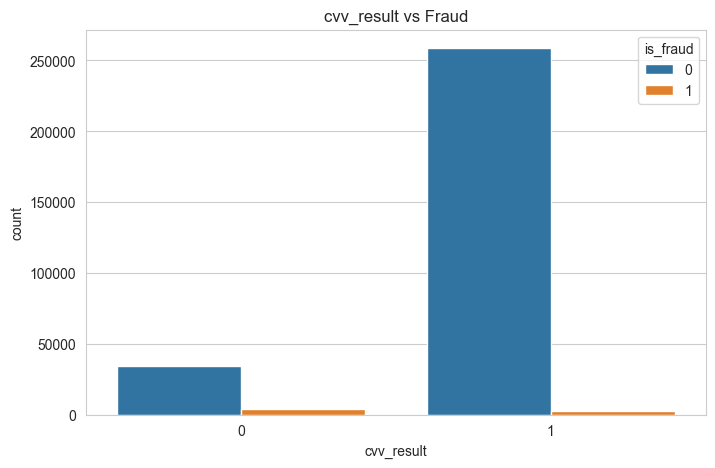

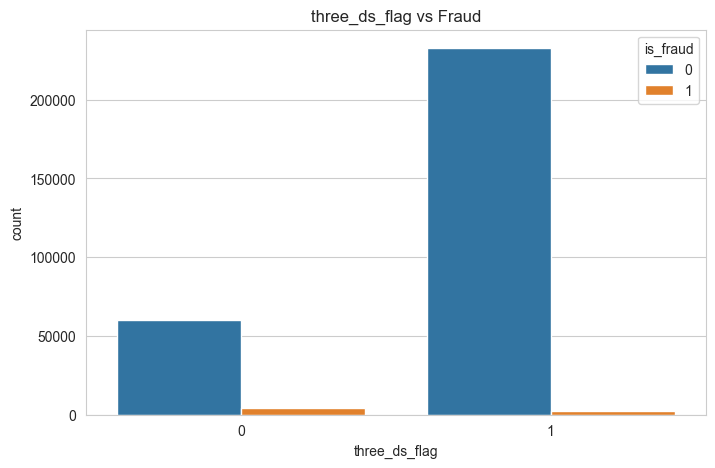

In [120]:
important_cat = ['channel', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag']

for col in important_cat:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, hue='is_fraud', data=df)
    plt.title(f"{col} vs Fraud")
    plt.show()

# ধাপ ৮: সময়-ভিত্তিক প্যাটার্ন (transaction_time)

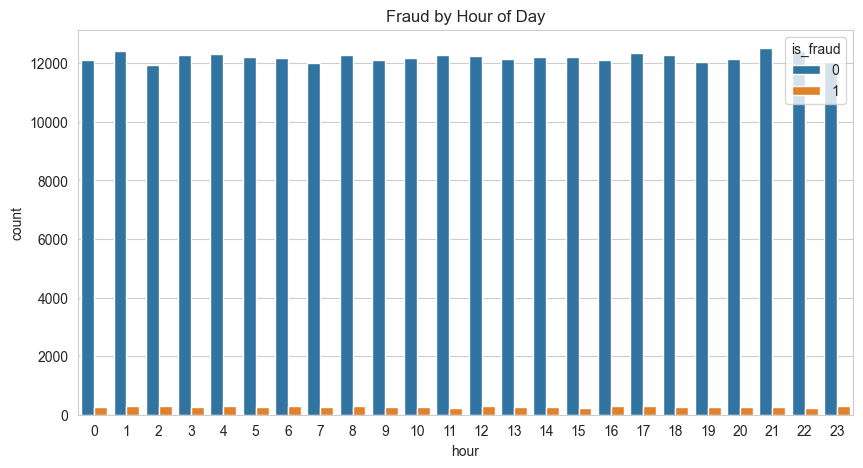

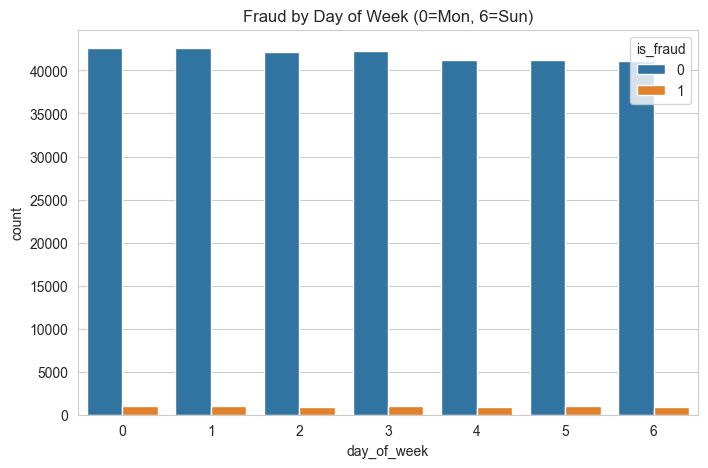

In [121]:
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df['hour'] = df['transaction_time'].dt.hour
df['day_of_week'] = df['transaction_time'].dt.dayofweek

plt.figure(figsize=(10,5))
sns.countplot(x='hour', hue='is_fraud', data=df)
plt.title("Fraud by Hour of Day")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(x='day_of_week', hue='is_fraud', data=df)
plt.title("Fraud by Day of Week (0=Mon, 6=Sun)")
plt.show()


# ধাপ ৯: Preprocessing-এর প্রস্তুতি

এখন থেকে আমরা ডেটা পরিবর্তন করব:

In [128]:
# 1. মিসিং ভ্যালু হ্যান্ডেল (যদি থাকে)
# df.fillna({...}) বা drop করা

# 2. ক্যাটাগরিক্যাল এনকোডিং
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

categorical_cols = ['country', 'bin_country', 'channel', 'merchant_category']

# যেগুলো dataframe-এ এখনও আছে শুধু সেগুলো encode করবে
existing_cats = [col for col in categorical_cols if col in df.columns]

if existing_cats:
    df = pd.get_dummies(df, columns=existing_cats, drop_first=True)

# 3. Scaling (amount, shipping_distance_km ইত্যাদি)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
to_scale = ['amount', 'shipping_distance_km', 'avg_amount_user']

existing_scale = [col for col in to_scale if col in df.columns]
df[existing_scale] = scaler.fit_transform(df[existing_scale])
print("Step 9 done")
print("Shape:", df.shape)
print("Columns:", len(df.columns))



Step 9 done
Shape: (299695, 41)
Columns: 41


# ধাপ ১০: নতুন ফিচার তৈরি (Feature Engineering)

In [129]:
# 1. amount > avg_amount_user কিনা
df['above_avg_amount'] = (df['amount'] > df['avg_amount_user']).astype(int)

# 2. দেশ মিলছে কিনা (dummy column থেকে)
country_cols = [c for c in df.columns if c.startswith('country_')]
bin_country_cols = [c.replace('country_', 'bin_country_') for c in country_cols]

df['same_country'] = (
    df[country_cols].values == df[bin_country_cols].values
).all(axis=1).astype(int)

# 3. অস্বাভাবিক দূরত্ব
df['far_shipping'] = (df['shipping_distance_km'] > 1000).astype(int)
print("Step 10 done")
print(df[['above_avg_amount', 'same_country', 'far_shipping']].head())



Step 10 done
   above_avg_amount  same_country  far_shipping
0                 0             1             0
1                 0             1             0
2                 0             1             0
3                 0             1             0
4                 0             0             0
